# 02 - BCA Assumptions and EDA

This notebook consumes the completed preprocessing outputs from `01-preprocessing.ipynb` and produces the empirical summaries used by the two modeling notebooks: log-skew-t and KDE.

## Load Preprocessed BCA Outputs

This first code block loads `bca_long.csv` and `bca_wide.csv` from Notebook 1. The long file is the canonical table for downstream analysis: each row is one baseline intensity measurement at a specific dwell time, file, lab, set, and amu tag. The wide file preserves cycle-aligned dwell-time channels for cross-dwell correlation and representative time-series checks.

This loading step is needed because every later assumption check depends on the same cleaned CSV outputs from preprocessing.

What we are looking for: both CSV files should load without parser errors, the long table should contain the columns needed for grouping by lab, set, run, dwell time, mass tag, and intensity, and no residual negative intensities should remain after preprocessing.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

ROOT = Path.cwd()
BCA_LONG_CSV_PATH = ROOT / 'bca_long.csv'
BCA_WIDE_CSV_PATH = ROOT / 'bca_wide.csv'

missing_paths = [path for path in [BCA_LONG_CSV_PATH, BCA_WIDE_CSV_PATH] if not path.exists()]
if missing_paths:
    missing = ', '.join(path.name for path in missing_paths)
    raise FileNotFoundError(f'Missing {missing}. Run 01-preprocessing.ipynb first.')

bca_long = pd.read_csv(BCA_LONG_CSV_PATH)
bca_wide = pd.read_csv(BCA_WIDE_CSV_PATH)

required_long_columns = {'lab', 'run_id', 'dwell_time', 'amu', 'time_sec', 'intensity'}
missing_long_columns = required_long_columns.difference(bca_long.columns)
if missing_long_columns:
    raise ValueError(f'bca_long.csv is missing columns: {sorted(missing_long_columns)}')
if 'label' not in bca_long.columns:
    dwell_labels = bca_long['dwell_time'].map(lambda value: f'{float(value):g}')
    bca_long['label'] = dwell_labels + '_' + bca_long['amu'].astype(str)

loaded_negative_count = int((bca_long['intensity'] < 0).sum())
invalid_negative_count = loaded_negative_count
if loaded_negative_count:
    bca_long = bca_long.loc[bca_long['intensity'] >= 0].reset_index(drop=True)
print({
    'long_rows_after_negative_filter': len(bca_long),
    'wide_rows': len(bca_wide),
    'negative_values_found_on_load': loaded_negative_count,
    'mass_tags': sorted(bca_long['amu'].dropna().unique()),
})
bca_long.head()


{'long_rows_after_negative_filter': 492000, 'wide_rows': 82000, 'negative_values_found_on_load': 0, 'mass_tags': ['5 amu', '6 amu', '9 amu']}


,lab,set,run_id,dwell_time,amu,time_sec,intensity,label
0,glasgow,dwell time calibration 1,He 656,0.128,5 amu,5.910,3.444608e-14,0.128_5 amu
1,glasgow,dwell time calibration 1,He 656,0.128,5 amu,14.022,1.187402e-14,0.128_5 amu
2,glasgow,dwell time calibration 1,He 656,0.128,5 amu,22.039,2.081396e-14,0.128_5 amu
3,glasgow,dwell time calibration 1,He 656,0.128,5 amu,30.155,4.212347e-15,0.128_5 amu
4,glasgow,dwell time calibration 1,He 656,0.128,5 amu,38.265,2.766935e-14,0.128_5 amu


### Output Interpretation

The completed run loaded 372,037 BCA observations across six Prisma Pro dwell times. This confirms that Notebook 1 produced a usable long-format dataset for the modeling pipeline.


## Marginal summaries by dwell time

## Compute Marginal Distribution Summaries

This block summarizes the valid nonnegative intensity distribution separately for each dwell time. It computes center, spread, quantiles, skewness, kurtosis, and counts of any remaining negative/nonpositive values.

This is needed because negative post-correction values are invalid and have been removed. Log-skew-t still needs strictly positive support, while KDE can follow the empirical nonnegative distribution.

What we are looking for: confirmation that no negative values remain, whether any zeros remain, whether the distributions are skewed or heavy-tailed, and whether some dwell times contain unusual extremes that could dominate model fitting.


In [2]:
def q(p):
    return lambda x: x.quantile(p)

eda_summary = (
    bca_long.groupby('dwell_time')['intensity']
    .agg(
        n='count',
        mean='mean',
        median='median',
        sd='std',
        min='min',
        q01=q(0.01),
        q05=q(0.05),
        q25=q(0.25),
        q75=q(0.75),
        q95=q(0.95),
        q99=q(0.99),
        max='max',
        skew=lambda x: x.skew(),
        excess_kurtosis=lambda x: x.kurt(),
        negative_count=lambda x: int((x < 0).sum()),
        nonpositive_count=lambda x: int((x <= 0).sum()),
    )
    .reset_index()
)
eda_summary['negative_fraction'] = eda_summary['negative_count'] / eda_summary['n']
eda_summary['nonpositive_fraction'] = eda_summary['nonpositive_count'] / eda_summary['n']
eda_summary.to_csv('eda_summary.csv', index=False)
eda_summary

,dwell_time,n,mean,median,sd,min,q01,q05,q25,q75,q95,q99,max,skew,excess_kurtosis,negative_count,nonpositive_count,negative_fraction,nonpositive_fraction
0,0.128,82000,3.927737e-14,2.985517e-14,3.486803e-14,0.000000e+00,5.466748e-16,2.765873e-15,1.401155e-14,5.421912e-14,1.084012e-13,1.581185e-13,6.869328e-13,1.777423,5.751742,0,2,0.0,0.000024
1,0.256,82000,2.489833e-14,1.955941e-14,2.138925e-14,1.770734e-21,3.657729e-16,1.779763e-15,9.111112e-15,3.449809e-14,6.661927e-14,9.840546e-14,2.392421e-13,1.620157,3.858882,0,0,0.0,0.000000
2,0.512,82000,1.564950e-14,1.266198e-14,1.291978e-14,0.000000e+00,2.428686e-16,1.183480e-15,5.946742e-15,2.181375e-14,4.080864e-14,5.835083e-14,2.440526e-13,1.541517,4.393169,0,1,0.0,0.000012
3,1.024,82000,1.025197e-14,8.606873e-15,7.973208e-15,2.905544e-22,1.662625e-16,8.184401e-16,4.178078e-15,1.437735e-14,2.556637e-14,3.603126e-14,8.420094e-14,1.293846,2.417650,0,0,0.0,0.000000
4,2.048,82000,7.162059e-15,6.362770e-15,5.127741e-15,2.517210e-19,1.274783e-16,6.331709e-16,3.161397e-15,1.010323e-14,1.664883e-14,2.279445e-14,5.412228e-14,1.050556,1.711320,0,0,0.0,0.000000
5,4.096,82000,5.642395e-15,5.255533e-15,3.703078e-15,6.174281e-22,1.073888e-16,5.546986e-16,2.683129e-15,8.009642e-15,1.224559e-14,1.594981e-14,3.377110e-14,0.738632,0.684623,0,0,0.0,0.000000


### Output Interpretation

Negative values after baseline reversal are treated as invalid and removed before these summaries are computed. The negative counts should therefore be zero; any remaining nonpositive counts are zeros, not negative observations.

The table also reveals extreme maxima at 0.128 s and 2.048 s. Those values inflate means, standard deviations, skewness, and kurtosis, so median and quantile summaries should receive more weight than the mean when judging the typical baseline scale.


## Lab-Level Assumption Checks

The dwell-time summaries pool Glasgow, Salzburg, and Wuhan. This section checks whether those labs differ materially in distribution center, spread, upper-tail behavior, or zero-value frequency after invalid negative values have been removed. Material lab differences would argue for lab-aware QC, stratified diagnostics, or lab terms in later models rather than treating all BCA files as exchangeable.

### Lab-Level Summary Tables

The first table summarizes each lab-dwell combination. The second table pools over dwell time to give a coarse lab-level audit. The lab-dwell table is the more important comparison because dwell time strongly changes the distribution.

In [3]:
lab_dwell_summary = (
    bca_long.groupby(['lab', 'dwell_time'])['intensity']
    .agg(
        n='count',
        mean='mean',
        median='median',
        sd='std',
        q05=q(0.05),
        q25=q(0.25),
        q75=q(0.75),
        q95=q(0.95),
        q99=q(0.99),
        negative_count=lambda x: int((x < 0).sum()),
        nonpositive_count=lambda x: int((x <= 0).sum()),
    )
    .reset_index()
)
lab_dwell_summary['negative_fraction'] = lab_dwell_summary['negative_count'] / lab_dwell_summary['n']
lab_dwell_summary['nonpositive_fraction'] = lab_dwell_summary['nonpositive_count'] / lab_dwell_summary['n']

lab_summary = (
    bca_long.groupby('lab')['intensity']
    .agg(
        n='count',
        mean='mean',
        median='median',
        sd='std',
        q05=q(0.05),
        q25=q(0.25),
        q75=q(0.75),
        q95=q(0.95),
        q99=q(0.99),
        negative_count=lambda x: int((x < 0).sum()),
        nonpositive_count=lambda x: int((x <= 0).sum()),
    )
    .reset_index()
)
lab_summary['negative_fraction'] = lab_summary['negative_count'] / lab_summary['n']
lab_summary['nonpositive_fraction'] = lab_summary['nonpositive_count'] / lab_summary['n']

lab_dwell_summary

,lab,dwell_time,n,mean,median,sd,q05,q25,q75,q95,q99,negative_count,nonpositive_count,negative_fraction,nonpositive_fraction
0,glasgow,0.128,14000,2.134485e-14,1.883757e-14,1.497308e-14,1.769895e-15,9.265397e-15,3.085516e-14,4.933777e-14,6.241461e-14,0,1,0.0,0.000071
1,glasgow,0.256,14000,1.472402e-14,1.311197e-14,1.037404e-14,1.201464e-15,6.281158e-15,2.146145e-14,3.389525e-14,4.335458e-14,0,0,0.0,0.000000
2,glasgow,0.512,14000,1.068373e-14,9.665591e-15,7.306091e-15,9.114963e-16,4.749952e-15,1.547306e-14,2.425399e-14,3.024083e-14,0,0,0.0,0.000000
3,glasgow,1.024,14000,8.298953e-15,7.838665e-15,5.129919e-15,9.133392e-16,4.237913e-15,1.174940e-14,1.747702e-14,2.147330e-14,0,0,0.0,0.000000
4,glasgow,2.048,14000,7.255458e-15,7.201627e-15,3.521027e-15,1.467809e-15,4.741966e-15,9.655264e-15,1.318867e-14,1.567092e-14,0,0,0.0,0.000000
5,glasgow,4.096,14000,6.891755e-15,6.886609e-15,2.437955e-15,2.889796e-15,5.218116e-15,8.538451e-15,1.089656e-14,1.266064e-14,0,0,0.0,0.000000
6,nineamu,0.128,20000,5.069502e-14,4.180358e-14,4.080593e-14,3.606945e-15,1.935715e-14,7.213593e-14,1.280022e-13,1.804529e-13,0,0,0.0,0.000000
7,nineamu,0.256,20000,3.170773e-14,2.602283e-14,2.551408e-14,2.428472e-15,1.202530e-14,4.484128e-14,8.163832e-14,1.134871e-13,0,0,0.0,0.000000
8,nineamu,0.512,20000,1.956295e-14,1.624802e-14,1.549915e-14,1.524806e-15,7.656249e-15,2.770041e-14,4.931455e-14,6.833681e-14,0,0,0.0,0.000000
9,nineamu,1.024,20000,1.225045e-14,1.021504e-14,9.499357e-15,9.354394e-16,4.810391e-15,1.753175e-14,3.055658e-14,4.175227e-14,0,0,0.0,0.000000


In [4]:
lab_summary

,lab,n,mean,median,sd,q05,q25,q75,q95,q99,negative_count,nonpositive_count,negative_fraction,nonpositive_fraction
0,glasgow,84000,1.153313e-14,8.643967e-15,9.893602e-15,1.343139e-15,5.252500e-15,1.451903e-14,3.223174e-14,4.805070e-14,0,1,0.0,0.000012
1,nineamu,120000,2.131303e-14,1.174590e-14,2.639683e-14,9.861122e-16,5.007411e-15,2.692635e-14,7.531996e-14,1.255794e-13,0,0,0.0,0.000000
2,salzburg,198000,1.887720e-14,1.002667e-14,2.395543e-14,7.922889e-16,4.181239e-15,2.385343e-14,6.777184e-14,1.140558e-13,0,2,0.0,0.000010
3,wuhan,90000,1.302514e-14,9.131673e-15,1.302685e-14,9.734011e-16,4.646292e-15,1.664769e-14,3.940840e-14,6.115734e-14,0,0,0.0,0.000000


### Lab-Level Center, Spread, and Tail Curves

These panels compare each lab across dwell time. Median checks center, IQR checks distribution body spread, and the 95th/99th percentiles check upper-tail behavior. Parallel curves suggest labs differ mostly by a stable offset; crossings or one lab separating only in the tail suggest lab-specific distribution shape differences.

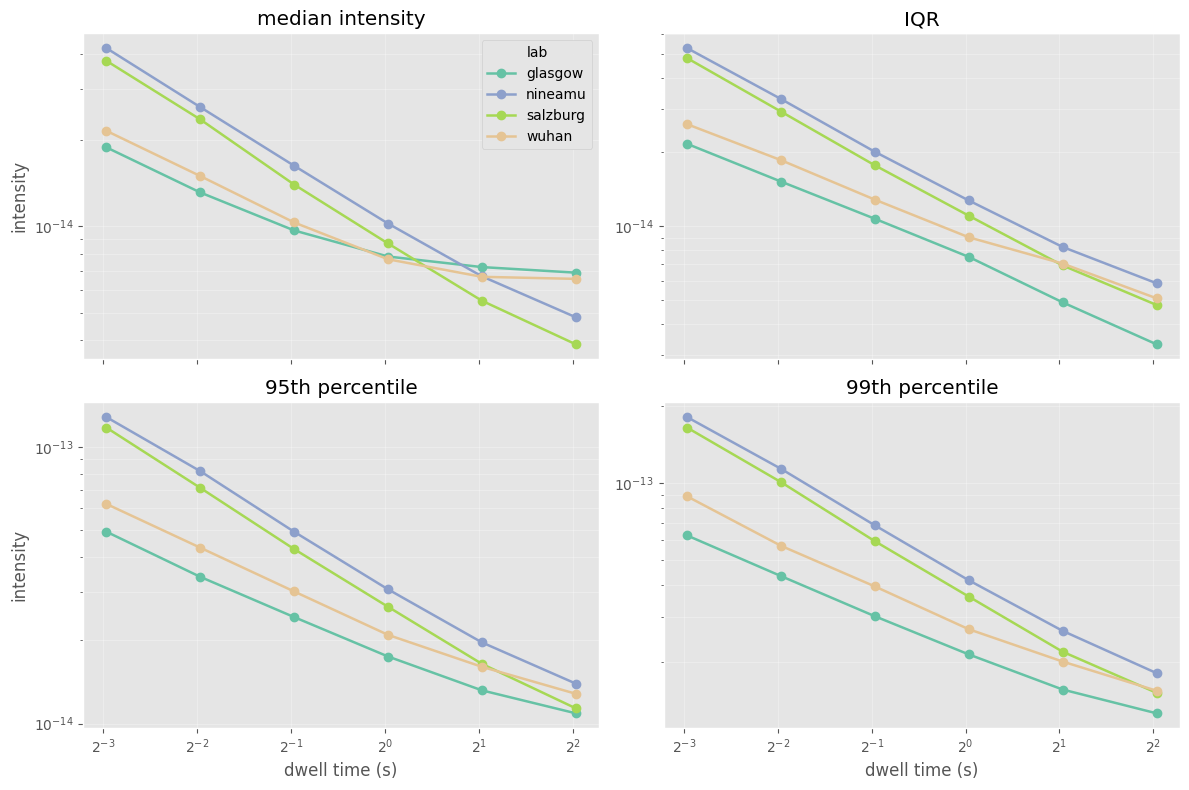

In [5]:
lab_dwell_summary['iqr'] = lab_dwell_summary['q75'] - lab_dwell_summary['q25']
lab_names = sorted(lab_dwell_summary['lab'].unique())
lab_colors = dict(zip(lab_names, plt.cm.Set2(np.linspace(0.05, 0.85, len(lab_names)))))
lab_metrics = [
    ('median', 'median intensity'),
    ('iqr', 'IQR'),
    ('q95', '95th percentile'),
    ('q99', '99th percentile'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (metric, label) in zip(axes.flat, lab_metrics):
    for lab in lab_names:
        subset = lab_dwell_summary.loc[lab_dwell_summary['lab'] == lab].sort_values('dwell_time')
        y = subset[metric].to_numpy(float)
        y_plot = np.where(y > 0, y, np.nan)
        ax.plot(subset['dwell_time'], y_plot, marker='o', linewidth=1.8, label=lab, color=lab_colors[lab])
    ax.set_title(label)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel('dwell time (s)')
for ax in axes[:, 0]:
    ax.set_ylabel('intensity')
axes[0, 0].legend(title='lab', framealpha=0.9)
plt.tight_layout()
plt.show()

## Pooled Dwell Times

### Pooled Histograms by Dwell Time

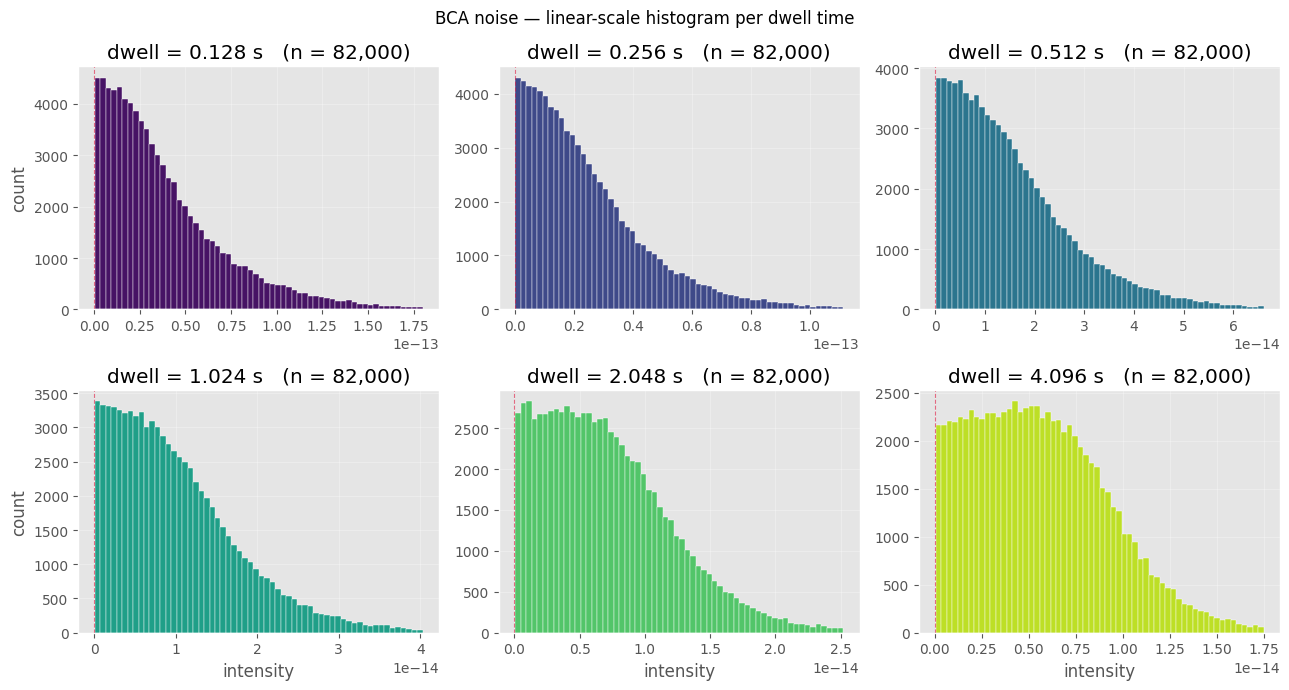

In [ ]:
dwell_times = sorted(eda_summary['dwell_time'].astype(float))
colors = plt.cm.viridis(np.linspace(0.05, 0.9, len(dwell_times)))

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=False)
fig.suptitle("BCA noise — linear-scale histogram per dwell time")

for ax, d, color in zip(axes.flat, dwell_times, colors):
    v = bca_long.loc[bca_long["dwell_time"] == d, "intensity"].astype(float).values
    
    # trim extreme tails
    lo, hi = np.percentile(v, [0.5, 99.5])
    v_trim = v[(v >= lo) & (v <= hi)]
    
    ax.hist(v_trim, bins=60, color=color, edgecolor="white", linewidth=0.3)
    ax.set_title(f"dwell = {d} s   (n = {len(v):,})")
    ax.axvline(0, color="crimson", lw=0.8, ls="--", alpha=0.6)
    ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('intensity')  # fixed label

for ax in axes[:, 0]:
    ax.set_ylabel('count')

plt.tight_layout()
plt.show()

### Pooled Log10 Histograms by Dwell Time

These histograms compare the shape, center, spread, and tail behavior of positive BCA intensities across dwell times on a common log10 scale. If one parametric family is plausible across dwell times, the panels should have broadly similar shapes after location/scale changes. Strong asymmetry, shoulders, or extreme tails argue for dwell-specific or empirical modeling.

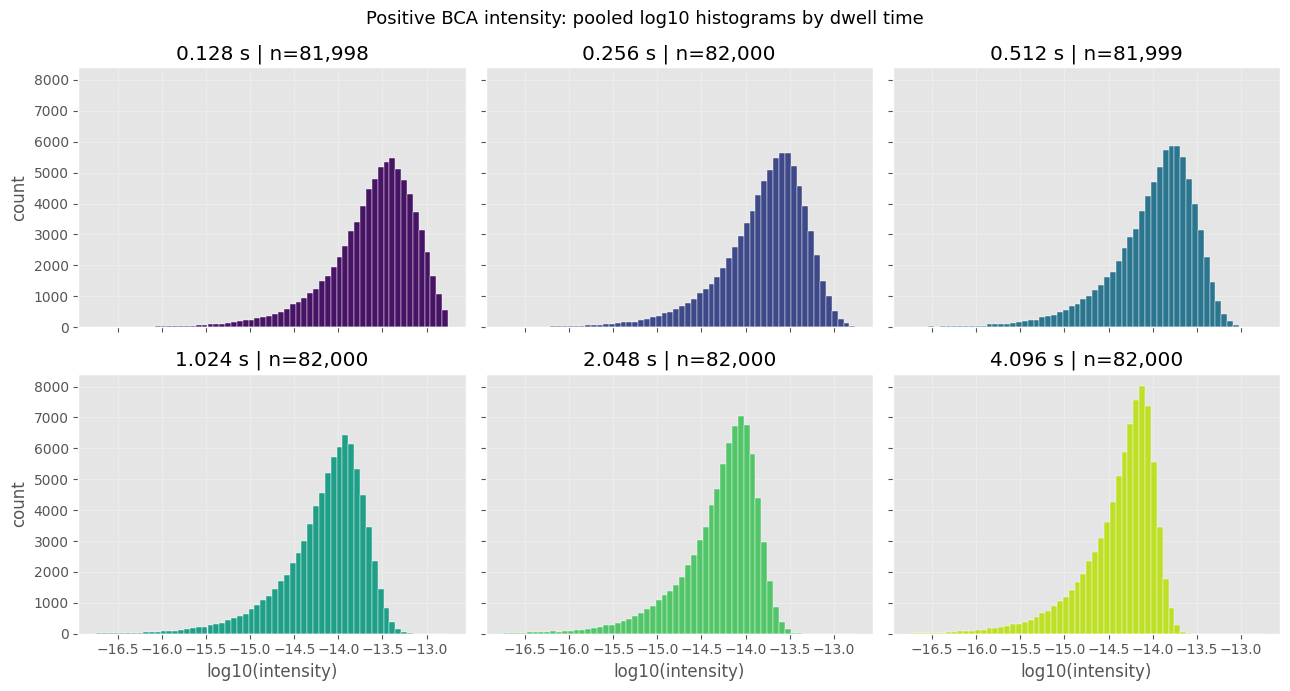

In [11]:
positive_bca = bca_long.loc[bca_long['intensity'] > 0, ['dwell_time', 'intensity']].copy()
positive_bca['log10_intensity'] = np.log10(positive_bca['intensity'])

dwell_times = sorted(eda_summary['dwell_time'].astype(float))
colors = plt.cm.viridis(np.linspace(0.05, 0.9, len(dwell_times)))

lo, hi = positive_bca['log10_intensity'].quantile([0.001, 0.999])
bin_edges = np.linspace(lo, hi, 61)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
fig.suptitle('Positive BCA intensity: pooled log10 histograms by dwell time', fontsize=13)

for ax, dwell, color in zip(axes.flat, dwell_times, colors):
    vals = positive_bca.loc[positive_bca['dwell_time'] == dwell, 'log10_intensity']
    nonpositive = int(eda_summary.loc[eda_summary['dwell_time'] == dwell, 'nonpositive_count'].iloc[0])
    ax.hist(vals, bins=bin_edges, color=color, edgecolor='white', linewidth=0.3)
    ax.set_title(f'{dwell:g} s | n={len(vals):,}')
    ax.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('log10(intensity)')
for ax in axes[:, 0]:
    ax.set_ylabel('count')

plt.tight_layout()
plt.show()

### Overlaid Pooled Histograms

The overlay makes dwell-time shifts easier to compare directly. Separation between curves indicates that dwell time changes the baseline-noise distribution, while differences in curve shape indicate that a simple shared distribution with only a location shift may be too restrictive.

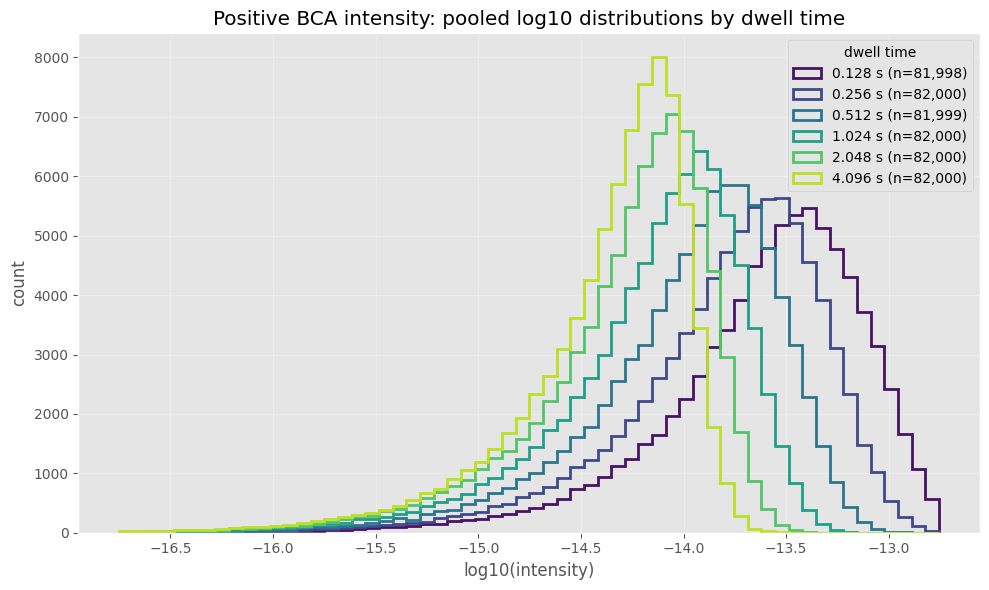

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
for dwell, color in zip(dwell_times, colors):
    vals = positive_bca.loc[positive_bca['dwell_time'] == dwell, 'log10_intensity']
    ax.hist(
        vals,
        bins=bin_edges,
        histtype='step',
        linewidth=2,
        color=color,
        label=f'{dwell:g} s (n={len(vals):,})',
    )

ax.set_title('Positive BCA intensity: pooled log10 distributions by dwell time')
ax.set_xlabel('log10(intensity)')
ax.set_ylabel('count')
ax.legend(title='dwell time', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Q-Q Plots by Dwell Time

These Q-Q plots compare each dwell-time pool of positive log10 intensities with a normal distribution. Points that bend away from the reference line show skewness, heavy tails, mixtures, or outliers. This is a direct visual check for the normal-on-log-scale assumption that motivates log-family models.

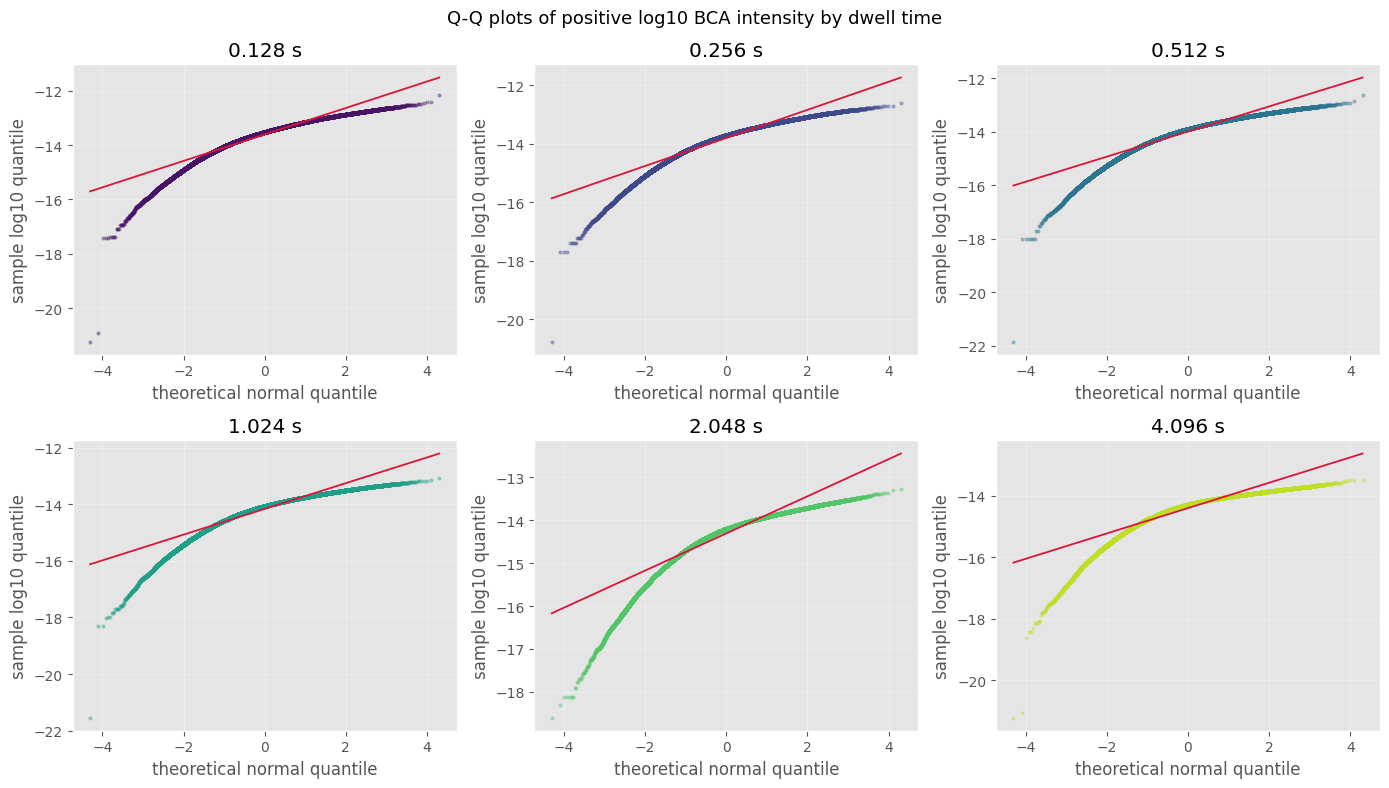

In [13]:
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Q-Q plots of positive log10 BCA intensity by dwell time', fontsize=13)

for ax, dwell, color in zip(axes.flat, dwell_times, colors):
    vals = positive_bca.loc[positive_bca['dwell_time'] == dwell, 'log10_intensity'].dropna().to_numpy()
    stats.probplot(vals, dist='norm', plot=ax)
    ax.get_lines()[0].set_marker('o')
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[0].set_markerfacecolor(color)
    ax.get_lines()[0].set_markeredgecolor(color)
    ax.get_lines()[0].set_alpha(0.35)
    ax.get_lines()[1].set_color('crimson')
    ax.get_lines()[1].set_linewidth(1.3)
    ax.set_title(f'{dwell:g} s')
    ax.set_xlabel('theoretical normal quantile')
    ax.set_ylabel('sample log10 quantile')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Distribution Body and Tail Summary

The boxplot provides a compact view of median, interquartile range, and outliers on the same positive log10 scale. It complements the histograms by making dwell-time shifts and tail asymmetry easier to scan.

C:\Users\Austin\AppData\Local\Temp\ipykernel_11356\1280566164.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=[f'{d:g}' for d in dwell_times], showfliers=False)


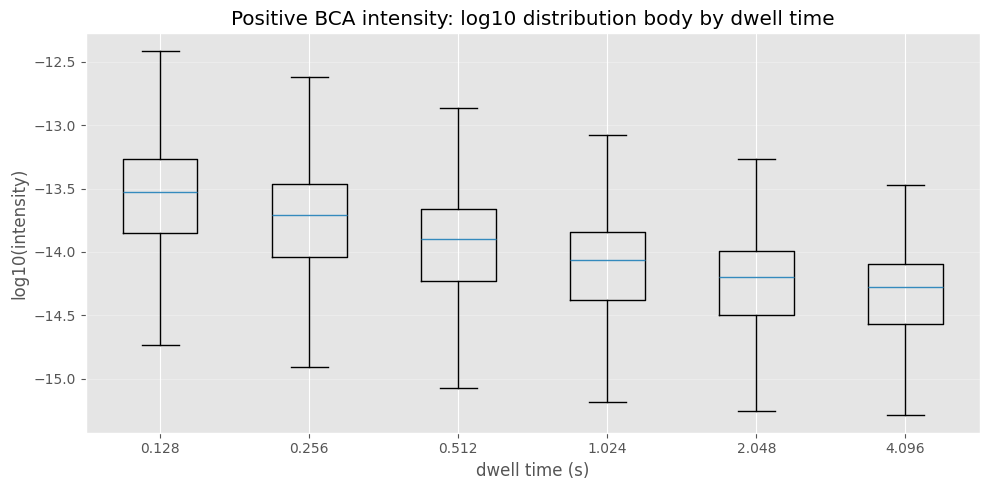

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
box_data = [
    positive_bca.loc[positive_bca['dwell_time'] == dwell, 'log10_intensity'].dropna().to_numpy()
    for dwell in dwell_times
]
ax.boxplot(box_data, labels=[f'{d:g}' for d in dwell_times], showfliers=False)
ax.set_title('Positive BCA intensity: log10 distribution body by dwell time')
ax.set_xlabel('dwell time (s)')
ax.set_ylabel('log10(intensity)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Output Interpretation

Use these plots to decide whether the assumptions are visually credible before fitting models. The expected warning signs are: zero observations for a positive-support model, dwell-time-specific location/scale shifts, non-normal Q-Q curvature on the log scale, and tail behavior that differs across dwell times. Those signs support the project choice to fit dwell-specific models.

## Structure within BCA runs

Time-series plots and autocorrelation per dwell time per file.

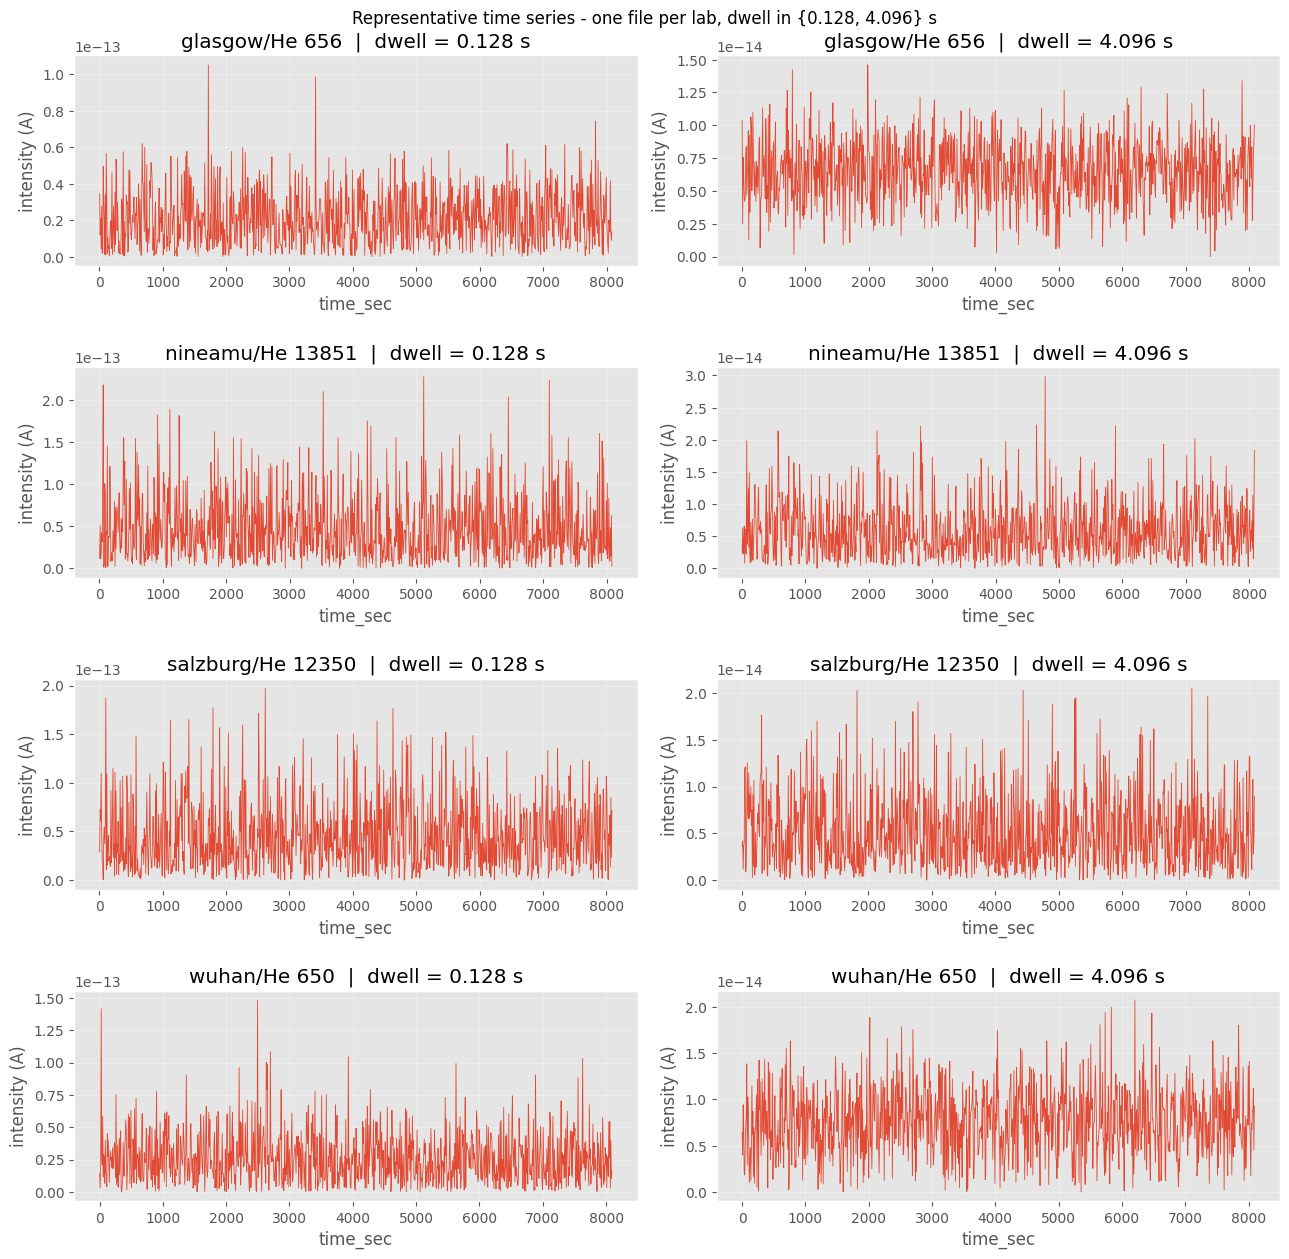

In [15]:
wide = bca_wide.copy()
labs = sorted(wide['lab'].dropna().unique())

rep_keys = []
for lab in labs:
    lab_rows = wide.loc[wide['lab'] == lab, ['lab', 'run_id']].drop_duplicates()
    if not lab_rows.empty:
        rep_keys.append(tuple(lab_rows.iloc[0]))

fig, axes = plt.subplots(len(rep_keys), 2, figsize=(13, 3.2 * len(rep_keys)), squeeze=False)
for row, (lab, run_id) in enumerate(rep_keys):
    df = wide.loc[(wide['lab'] == lab) & (wide['run_id'] == run_id)].sort_values('row_id')
    cols = [c for c in df.columns if c in ('0.128', '4.096')]
    for col_idx, col in enumerate(cols):
        ax = axes[row, col_idx]
        ax.plot(df['time_sec'], df[col], lw=0.6)
        ax.set_title(f'{lab}/{run_id}  |  dwell = {col} s')
        ax.set_xlabel('time_sec')
        ax.set_ylabel('intensity (A)')
        ax.grid(alpha=0.3)
fig.suptitle('Representative time series - one file per lab, dwell in {0.128, 4.096} s')
plt.tight_layout()
plt.show()


## Dwell-time dependence candidates

## Check Dwell-Time Dependence

This block fits simple curves to the dwell-time summaries. It compares linear-in-dwell, linear-in-log-dwell, and inverse-dwell relationships for mean, median, and standard deviation.

This is needed because baseline noise should change with dwell time. If the relationship is smooth, a joint parametric model can share information across dwell times. If the relationship is irregular, the empirical KDE approach becomes more attractive.

What we are looking for: which simple functional form best describes the location and scale summaries, while remembering that means and standard deviations can be distorted by extreme values.


In [16]:
def fit_curve(x, y, transform):
    z = transform(x)
    X = np.column_stack([np.ones_like(z), z])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    pred = X @ beta
    sse = float(np.sum((y - pred) ** 2))
    return beta, pred, sse

candidates = {
    'linear_d': lambda x: x,
    'linear_log_d': lambda x: np.log(x),
    'inverse_d': lambda x: 1 / x,
}

rows = []
x = eda_summary['dwell_time'].to_numpy(float)
for metric in ['mean', 'median', 'sd']:
    y = eda_summary[metric].to_numpy(float)
    for name, transform in candidates.items():
        beta, pred, sse = fit_curve(x, y, transform)
        rows.append({'metric': metric, 'model': name, 'intercept': beta[0], 'slope': beta[1], 'sse': sse})

dwell_dependence = pd.DataFrame(rows).sort_values(['metric', 'sse']).reset_index(drop=True)
dwell_dependence.to_csv('dwell_dependence.csv', index=False)
dwell_dependence

,metric,model,intercept,slope,sse
0,mean,inverse_d,5.786303e-15,4.431730e-15,8.124082e-30
1,mean,linear_log_d,1.412891e-14,-9.347891e-15,9.696507e-29
2,mean,linear_d,2.537708e-14,-6.123620e-15,3.994599e-28
3,median,inverse_d,5.390806e-15,3.247992e-15,5.123622e-30
4,median,linear_log_d,1.149925e-14,-6.869010e-15,5.076808e-29
5,median,linear_d,1.977233e-14,-4.505486e-15,2.135080e-28
6,sd,inverse_d,3.816552e-15,4.101317e-15,6.326719e-30
7,sd,linear_log_d,1.154139e-14,-8.637863e-15,8.431627e-29
8,sd,linear_d,2.192940e-14,-5.654182e-15,3.431661e-28


### Output Interpretation

Among the simple candidates tested, the inverse-dwell relationship had the lowest SSE for mean, median, and standard deviation. The median fits are the most trustworthy because they are less affected by the extreme maxima flagged in the marginal summary.

This supports using dwell-time-aware modeling, but it also warns that parametric curves fitted to means or standard deviations may be unstable unless the extreme values are reviewed.


## Power-Law Dwell-Time Dependence

The previous table compares simple linear, log-dwell, and inverse-dwell curves on raw marginal summaries. A physically useful dwell-time relationship may instead look like a power law: `summary = a * dwell_time^b`. On a log-log plot, that relationship is a straight line, and the exponent `b` describes how quickly a noise summary changes as dwell time doubles. This section tests that idea using positive-intensity summaries so the log transform is well-defined.

### Positive-Intensity Summary Curves

These curves show how the distribution body and upper tail move with dwell time before fitting any curve. The median and IQR describe the stable body of the distribution; the 95th and 99th percentiles show whether tail risk scales differently from the center.

In [17]:
positive_dwell_summary = (
    positive_bca.groupby('dwell_time')['intensity']
    .agg(
        positive_n='count',
        positive_mean='mean',
        positive_median='median',
        positive_sd='std',
        positive_q05=lambda x: x.quantile(0.05),
        positive_q25=lambda x: x.quantile(0.25),
        positive_q75=lambda x: x.quantile(0.75),
        positive_q95=lambda x: x.quantile(0.95),
        positive_q99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)
positive_dwell_summary['positive_iqr'] = positive_dwell_summary['positive_q75'] - positive_dwell_summary['positive_q25']
positive_dwell_summary = positive_dwell_summary.merge(
    eda_summary[['dwell_time', 'nonpositive_fraction']],
    on='dwell_time',
    how='left',
)
positive_dwell_summary

,dwell_time,positive_n,positive_mean,positive_median,positive_sd,positive_q05,positive_q25,positive_q75,positive_q95,positive_q99,positive_iqr,nonpositive_fraction
0,0.128,81998,3.927833e-14,2.985807e-14,3.486792e-14,2.765879e-15,1.401191e-14,5.422083e-14,1.084020e-13,1.581192e-13,4.020892e-14,0.000024
1,0.256,82000,2.489833e-14,1.955941e-14,2.138925e-14,1.779763e-15,9.111112e-15,3.449809e-14,6.661927e-14,9.840546e-14,2.538698e-14,0.000000
2,0.512,81999,1.564969e-14,1.266226e-14,1.291974e-14,1.183827e-15,5.946846e-15,2.181400e-14,4.080873e-14,5.835143e-14,1.586715e-14,0.000012
3,1.024,82000,1.025197e-14,8.606873e-15,7.973208e-15,8.184401e-16,4.178078e-15,1.437735e-14,2.556637e-14,3.603126e-14,1.019927e-14,0.000000
4,2.048,82000,7.162059e-15,6.362770e-15,5.127741e-15,6.331709e-16,3.161397e-15,1.010323e-14,1.664883e-14,2.279445e-14,6.941837e-15,0.000000
5,4.096,82000,5.642395e-15,5.255533e-15,3.703078e-15,5.546986e-16,2.683129e-15,8.009642e-15,1.224559e-14,1.594981e-14,5.326513e-15,0.000000


### Power-Law Fits

This block fits `summary = a * dwell_time^b` by regressing `log(summary)` on `log(dwell_time)`. It reports the multiplier `a`, exponent `b`, raw-scale SSE, and log-scale SSE. The log-scale SSE is the most natural comparison for a power-law check because the model is linear on the log scale.

In [18]:
def fit_power_law(dwell, values):
    dwell = np.asarray(dwell, dtype=float)
    values = np.asarray(values, dtype=float)
    mask = (dwell > 0) & (values > 0) & np.isfinite(values)
    log_x = np.log(dwell[mask])
    log_y = np.log(values[mask])
    X = np.column_stack([np.ones_like(log_x), log_x])
    beta, *_ = np.linalg.lstsq(X, log_y, rcond=None)
    fitted = np.exp(beta[0] + beta[1] * np.log(dwell))
    return {
        'a': float(np.exp(beta[0])),
        'exponent': float(beta[1]),
        'fitted': fitted,
        'sse_raw': float(np.sum((values - fitted) ** 2)),
        'sse_log': float(np.sum((np.log(values[mask]) - (X @ beta)) ** 2)),
        'n_fit': int(mask.sum()),
    }

power_metrics = [
    'positive_mean',
    'positive_median',
    'positive_sd',
    'positive_iqr',
    'positive_q95',
    'positive_q99',
]

power_rows = []
power_residual_rows = []
power_x = positive_dwell_summary['dwell_time'].to_numpy(float)
for metric in power_metrics:
    y = positive_dwell_summary[metric].to_numpy(float)
    fit = fit_power_law(power_x, y)
    power_rows.append({
        'metric': metric,
        'a': fit['a'],
        'exponent': fit['exponent'],
        'sse_raw': fit['sse_raw'],
        'sse_log': fit['sse_log'],
        'n_fit': fit['n_fit'],
    })
    for dwell, observed, fitted in zip(power_x, y, fit['fitted']):
        power_residual_rows.append({
            'metric': metric,
            'dwell_time': dwell,
            'observed': observed,
            'fitted': fitted,
            'residual': observed - fitted,
            'log_residual': np.log(observed) - np.log(fitted),
        })

power_law_fits = pd.DataFrame(power_rows).sort_values('sse_log').reset_index(drop=True)
power_law_residuals = pd.DataFrame(power_residual_rows)
power_law_fits

,metric,a,exponent,sse_raw,sse_log,n_fit
0,positive_q99,3.844008e-14,-0.673505,3.532942e-29,0.011357,6
1,positive_sd,8.609500e-15,-0.658667,3.005285e-30,0.016468,6
2,positive_q95,2.762529e-14,-0.640185,3.640269e-29,0.018216,6
3,positive_iqr,1.115667e-14,-0.595170,6.885099e-30,0.023663,6
4,positive_mean,1.131273e-14,-0.571423,9.293071e-30,0.029963,6
5,positive_median,9.611005e-15,-0.512813,7.247083e-30,0.036918,6


### Power-Law Fit Diagnostics

The log-log panels show observed summaries and fitted power-law curves. A plausible power law should track each metric as a near-straight line on these axes. Curvature, crossings, or one dwell time dominating the line indicate that a single exponent is not enough.

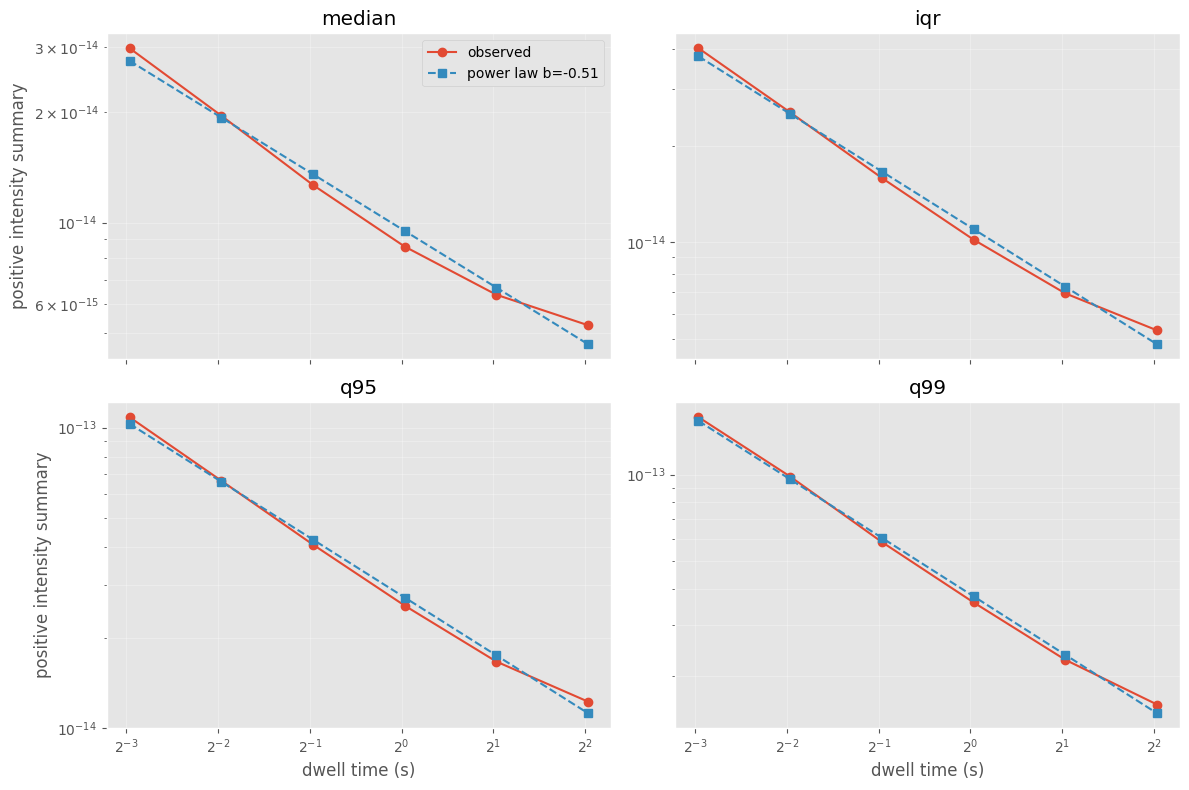

In [19]:
plot_metrics = ['positive_median', 'positive_iqr', 'positive_q95', 'positive_q99']
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, metric in zip(axes.flat, plot_metrics):
    subset = power_law_residuals.loc[power_law_residuals['metric'] == metric]
    exponent = power_law_fits.loc[power_law_fits['metric'] == metric, 'exponent'].iloc[0]
    ax.plot(subset['dwell_time'], subset['observed'], marker='o', label='observed')
    ax.plot(subset['dwell_time'], subset['fitted'], marker='s', linestyle='--', label=f'power law b={exponent:.2f}')
    ax.set_title(metric.replace('positive_', '').replace('_', ' '))
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel('dwell time (s)')
for ax in axes[:, 0]:
    ax.set_ylabel('positive intensity summary')
axes[0, 0].legend(framealpha=0.9)
plt.tight_layout()
plt.show()

### Power-Law Residuals

These residuals show where the power law misses each summary on the log scale. Log residuals above zero mean the observed summary is higher than the power-law prediction; values below zero mean it is lower. A trend across dwell time indicates remaining structure not captured by the power law.

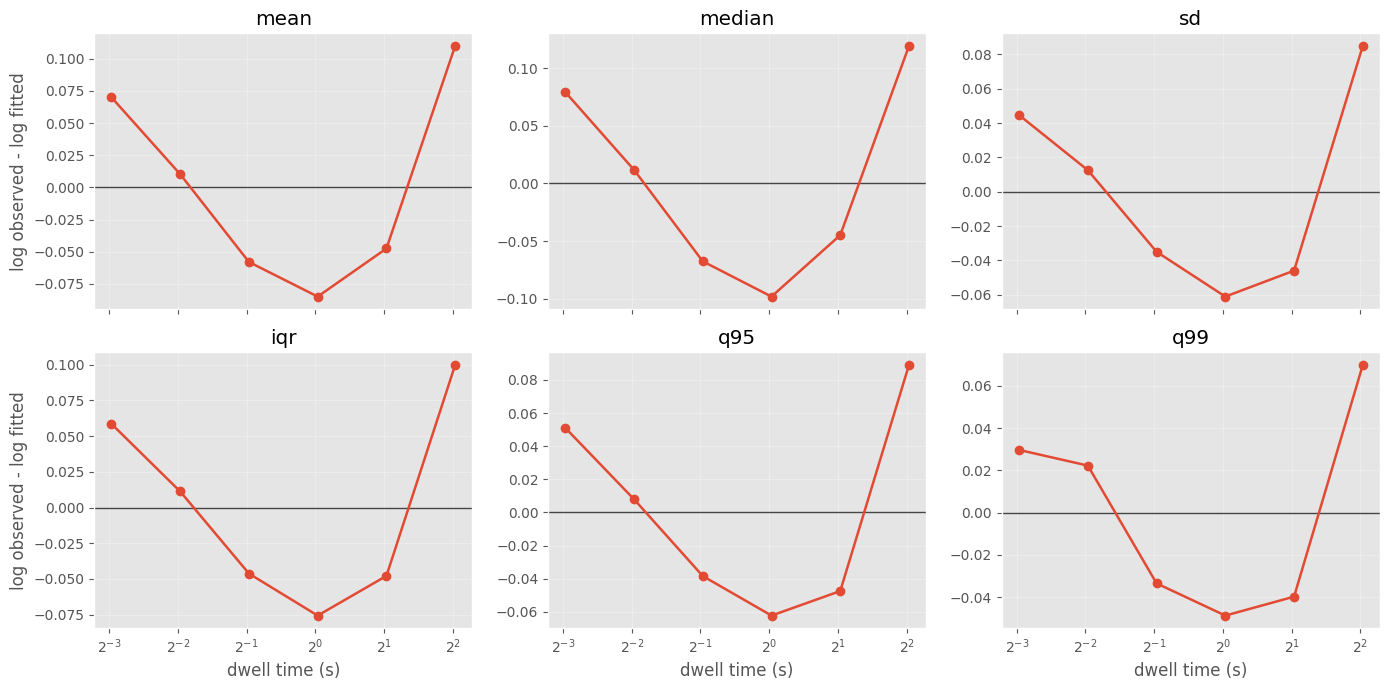

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for ax, metric in zip(axes.flat, power_metrics):
    subset = power_law_residuals.loc[power_law_residuals['metric'] == metric]
    ax.axhline(0, color='black', linewidth=1, alpha=0.7)
    ax.plot(subset['dwell_time'], subset['log_residual'], marker='o', linewidth=1.8)
    ax.set_title(metric.replace('positive_', '').replace('_', ' '))
    ax.set_xscale('log', base=2)
    ax.grid(True, alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel('dwell time (s)')
for ax in axes[:, 0]:
    ax.set_ylabel('log observed - log fitted')
plt.tight_layout()
plt.show()

### Output Interpretation

This section directly tests whether dwell-time dependence can be summarized as a power law. The most credible evidence would be near-linear log-log summary curves, similar exponents for body and tail summaries, and residuals without a dwell-time pattern. If the upper-tail exponents differ from the median or IQR exponent, dwell time is changing the distribution shape, which supports dwell-specific KDE or quantile modeling rather than a single pooled correction.

## Cross-dwell-time rank correlation

## Estimate Cross-Dwell-Time Rank Correlation

This block uses `bca_wide.csv` to compute Spearman correlations across dwell-time columns in the cycle-aligned wide data.

This is needed because the proposed baseline correction may transfer a live baseline reading at one dwell time to a signal channel at another dwell time using a shared quantile. That transfer assumption requires the dwell-time channels to move together within measurement cycles.

What we are looking for: strong positive rank correlations would support live-baseline quantile transfer. Weak or inconsistent correlations would mean marginal dwell-time modeling may be valid, but cycle-level transfer should be treated cautiously.


In [21]:
wide = bca_wide.copy()
dwell_cols = [c for c in wide.columns if c not in {'lab', 'run_id', 'row_id', 'time_sec'}]
corr_matrix = wide[dwell_cols].corr(method='spearman')
corr_matrix.to_csv('corr_matrix.csv')
corr_matrix


,0.128,0.256,0.512,1.024,2.048,4.096
0.128,1.000000,0.133511,0.074861,0.036007,-0.019487,-0.094837
0.256,0.133511,1.000000,0.089671,0.027737,-0.014404,-0.075180
0.512,0.074861,0.089671,1.000000,0.030181,0.001823,-0.051906
1.024,0.036007,0.027737,0.030181,1.000000,-0.019764,-0.027837
2.048,-0.019487,-0.014404,0.001823,-0.019764,1.000000,0.018628
4.096,-0.094837,-0.075180,-0.051906,-0.027837,0.018628,1.000000


### Output Interpretation

The mean off-diagonal Spearman correlation is 0.334. Some neighboring or longer dwell-time pairs are moderately correlated, especially 2.048 vs 4.096 s at 0.647, but other pairs are weak, such as 0.128 vs 1.024 s at 0.191.

This means live-baseline quantile transfer is only partially supported. It should be treated as a modeling assumption requiring validation, not as a guaranteed property of the BCA data.


### Spearman Correlation Heatmap

The numeric correlation matrix checks whether cycle-level ranks are shared across dwell times. The heatmap makes the dependence pattern easier to see: strong blocks support cross-dwell transfer assumptions, while weak or uneven cells argue for treating dwell-time channels separately.

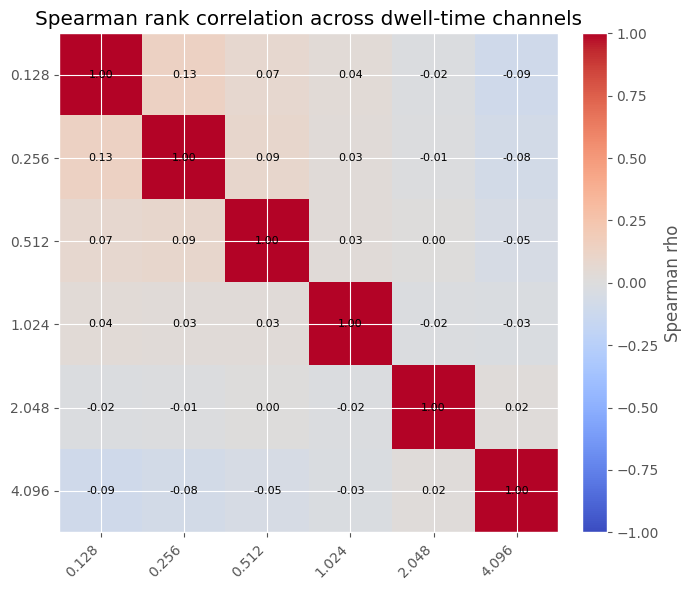

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix.to_numpy(), vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.index)
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Spearman rank correlation across dwell-time channels')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Spearman rho')
plt.tight_layout()
plt.show()

### Output Interpretation

The heatmap should be read as a diagnostic for the live-baseline or quantile-transfer assumption. Uniformly high correlations would support transferring information across dwell times. Patchy or moderate correlations mean the assumption is only partially supported and should be validated against downstream correction performance.

## Assumption summary

## Save a Compact Assumption Summary

This block writes the high-level facts from the EDA into `assumption_summary.json`. The summary is intentionally small: row count, file count, labs, dwell times, invalid-negative audit counts, and average cross-dwell correlation.

This is needed so reports and later notebooks can cite the same core facts without recomputing the entire EDA.

What we are looking for: a quick sanity check that the data volume, source labels, dwell-time grid, and residual-negative audit match expectations.


In [23]:
file_count = int(bca_long[['lab', 'run_id']].drop_duplicates().shape[0])
assumption_summary = {
    'rows': int(len(bca_long)),
    'files': file_count,
    'labs': sorted(map(str, bca_long['lab'].unique())),
    'dwell_times': sorted(map(float, bca_long['dwell_time'].unique())),
    'mass_tags': sorted(map(str, bca_long['amu'].dropna().unique())),
    'invalid_negative_values_removed': invalid_negative_count,
    'total_negative_values': int((bca_long['intensity'] < 0).sum()),
    'total_nonpositive_values': int((bca_long['intensity'] <= 0).sum()),
    'mean_spearman_offdiagonal': float(corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).stack().mean()),
}

assumption_summary

{'rows': 492000,
 'files': 73,
 'labs': ['glasgow', 'nineamu', 'salzburg', 'wuhan'],
 'dwell_times': [0.128, 0.256, 0.512, 1.024, 2.048, 4.096],
 'mass_tags': ['5 amu', '6 amu', '9 amu'],
 'invalid_negative_values_removed': 0,
 'total_negative_values': 0,
 'total_nonpositive_values': 3,
 'mean_spearman_offdiagonal': 0.0072669891465718395}

### Output Interpretation

The saved summary records the valid post-filter row count, set-aware BCA file count, three lab labels, six dwell times, mass tags, the number of invalid negative values removed, and the average cross-dwell correlation. These facts drive the later modeling choice: KDE is a strong empirical baseline, while log-skew-t should use only strictly positive observations.
